In [17]:
import pandas as pd
import glob
import os

In [18]:
keep_cols_inbound = ['N° de voyage', 'PTF départ.1', 'PTF arrivée.1', 'N° DC', 'Nb UM', 'Réalisé le', 'Numéro de colis flashé en arrivage']

In [19]:
folder_path = "/Users/guelbi/Desktop/explore/gr-forecast-ds-master/NTW-23280"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []
for f in csv_files:
    df = pd.read_csv(f, usecols=keep_cols_inbound, sep=";", encoding="ISO-8859-1")  # only read selected columns
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_8445/1987414072.py:7: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=keep_cols_inbound, sep=";", encoding="ISO-8859-1")  # only read selected columns
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_8445/1987414072.py:7: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=keep_cols_inbound, sep=";", encoding="ISO-8859-1")  # only read selected columns
/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_8445/1987414072.py:7: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, usecols=keep_cols_inbound, sep=";", encoding="ISO-8859-1")  # only read selected columns


In [23]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418630 entries, 2784883 to 5359746
Data columns (total 7 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   N° de voyage                        418630 non-null  object        
 1   PTF départ.1                        418630 non-null  object        
 2   PTF arrivée.1                       418630 non-null  object        
 3   N° DC                               418630 non-null  object        
 4   Nb UM                               418630 non-null  int64         
 5   Numéro de colis flashé en arrivage  418630 non-null  object        
 6   Réalisé le                          418630 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 25.6+ MB


In [21]:
combined['N° de voyage'] = combined['N° de voyage'].str.replace(r'^="|"$', '', regex=True)
combined['N° DC'] = combined['N° DC'].str.replace(r'^="|"$', '', regex=True)
combined = combined[combined['PTF arrivée.1'] == 'LYON']
combined['Nb UM'] = pd.to_numeric(combined['Nb UM'], errors="coerce")

In [22]:
# Ensure the date column is datetime
combined['Réalisé le'] = pd.to_datetime(combined['Réalisé le'], dayfirst=True, errors='coerce')

# Sort so the earliest date per package comes first
df_sorted = combined.sort_values(['N° DC', 'Réalisé le'], ascending=[True, True])
# Keep the first occurrence per package
combined = df_sorted.drop_duplicates(subset='N° DC', keep='first')

In [24]:
combined['N° DC'].nunique()

418630

In [25]:
voyage_col = "N° de voyage"  
voyage_agg = (
    combined.groupby(voyage_col, as_index=False)
      .agg(
          earliest_ts=("Réalisé le", "min"),   # earliest timestamp for the voyage
          total_nb_um=("Nb UM", "sum")       # total packages across all voyage rows
      )
)

voyage_agg["warehouse_day"] = (voyage_agg["earliest_ts"] - pd.Timedelta(hours=5)).dt.floor("D")

In [26]:
voyage_agg.head()

,N° de voyage,earliest_ts,total_nb_um,warehouse_day
0,T0012391326,2024-06-11 03:23:00,86,2024-06-10
1,T0012391333,2024-06-11 03:16:00,70,2024-06-10
2,T0012391537,2024-06-12 03:33:00,84,2024-06-11
3,T0012391544,2024-06-12 01:42:00,61,2024-06-11
4,T0012391782,2024-06-13 02:09:00,173,2024-06-12


In [27]:
date_col = "warehouse_day"
count_col = "total_nb_um"

day = voyage_agg[date_col].dt.date   # returns Python date objects
# Alternatively: day = df[date_col].dt.floor("D")  # keeps pandas datetime midnight

voyage_agg[count_col] = pd.to_numeric(voyage_agg[count_col], errors="coerce")

df_clean = voyage_agg.dropna(subset=[date_col, count_col])

# 4) Group by day and sum
daily_packages_inbound = (
    df_clean
    .groupby(day)[count_col]
    .sum()
    .sort_index()
)
daily_packages_inbound.index = pd.to_datetime(daily_packages_inbound.index)
daily_packages_inbound = daily_packages_inbound[
    daily_packages_inbound.index >= pd.Timestamp("2024-01-01")
]

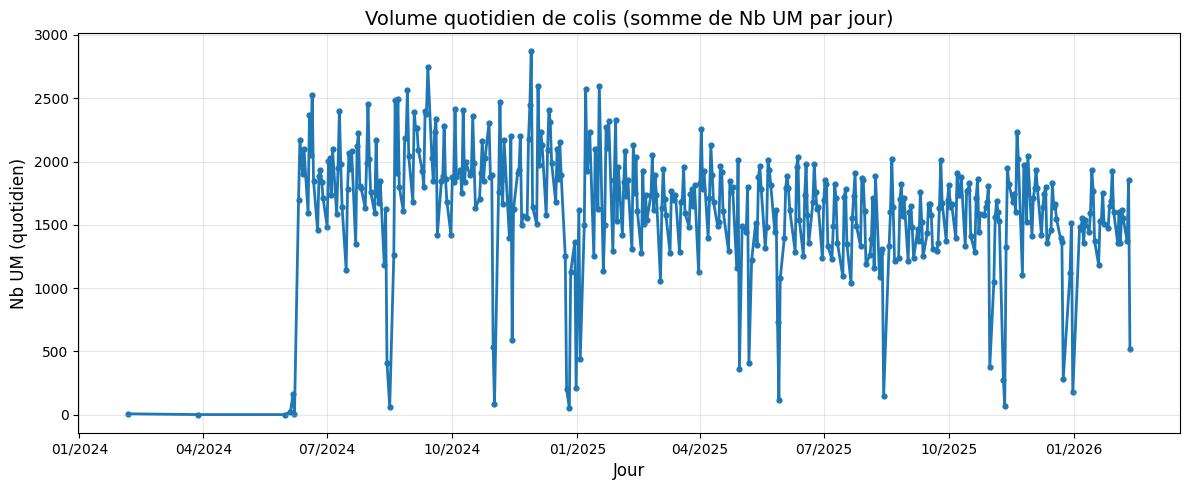

In [30]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter

# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(daily_packages_inbound.index, daily_packages_inbound.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(daily_packages_inbound.index, daily_packages_inbound.values, color="#1f77b4", s=12)

plt.tight_layout()



In [29]:
s = daily_packages_inbound.copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()   # ensure chronological order

# ---- Fold Saturdays: add to previous row ----
sat_mask = s.index.dayofweek == 5    # Saturdays
sat_positions = [s.index.get_loc(d) for d in s.index[sat_mask]]

for pos in sat_positions:
    if pos > 0:  # ensure there *is* a previous row
        s.iloc[pos - 1] += s.iloc[pos]   # add Saturday to previous row

# remove Saturdays
s = s[~sat_mask]

# ---- Fold Sundays: add to next row ----
sun_mask = s.index.dayofweek == 6    # Sundays
sun_positions = [s.index.get_loc(d) for d in s.index[sun_mask]]

# careful: iterate in reverse so shifting index doesn't affect upcoming positions
for pos in reversed(sun_positions):
    if pos < len(s) - 1:  # ensure there is a next row
        s.iloc[pos + 1] += s.iloc[pos]   # add Sunday to next row

# remove Sundays
s = s[~sun_mask]

## final sorted series
daily_packages_inbound = s.sort_index(ascending=False)

In [16]:
keep_cols_87 = ['N° de voyage', 'PTF départ.1', 'PTF arrivée.1', 'ARR_PLANNING_DATE', 'N° DC', 'Nb UM']

In [8]:
def detect_sep(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if line:  # first non-empty line
                semis = line.count(";")
                pipes = line.count("|")
                if semis == 0 and pipes == 0:
                    # Fall back to auto
                    return None
                return ";" if semis >= pipes else "|"

In [9]:
folder_path = "/Users/guelbi/Desktop/explore/gr-forecast-ds-master/NTW-23287"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []
for f in csv_files:
    sep = detect_sep(f)
    df = pd.read_csv(f, usecols=keep_cols_87, sep=sep, encoding="ISO-8859-1", on_bad_lines='skip', engine='python')  # only read selected columns
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

In [10]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15574387 entries, 0 to 15574386
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   N° de voyage       object
 1   PTF départ.1       object
 2   PTF arrivée.1      object
 3   N° DC              object
 4   Nb UM              object
 5   ARR_PLANNING_DATE  object
dtypes: object(6)
memory usage: 712.9+ MB


In [ ]:
combined['N° de voyage'] = combined['N° de voyage'].str.replace(r'^="|"$', '', regex=True)
#combined['N° DC'] = combined['N° DC'].str.replace(r'^="|"$', '', regex=True)
combined = combined[combined['PTF arrivée.1'] == 'LYON']
combined['Nb UM'] = pd.to_numeric(combined['Nb UM'], errors="coerce")

In [12]:
# Ensure the date column is datetime
combined['ARR_PLANNING_DATE'] = pd.to_datetime(combined['ARR_PLANNING_DATE'], dayfirst=True, errors='coerce')

# Sort so the earliest date per package comes first
df_sorted = combined.sort_values(['N° DC', 'ARR_PLANNING_DATE'], ascending=[True, True])
# Keep the first occurrence per package
combined = df_sorted.drop_duplicates(subset='N° DC', keep='first')

In [13]:
combined.head()

,N° de voyage,PTF départ.1,PTF arrivée.1,N° DC,Nb UM,ARR_PLANNING_DATE
14175545,T0092314980,MULHOUSE,GENNEVIL,13890951,1.0,2023-08-25 05:05:00
14175546,T0092314980,MULHOUSE,GENNEVIL,13918797,1.0,2023-08-25 05:05:00
5442053,T0912173852,TOULOUSE,GENNEVIL,13923938,1.0,2023-12-19 06:00:00
7237448,T0242196605,MOISSY,GENNEVIL,13931099,5.0,2023-08-11 20:30:00
14175549,T0092314980,MULHOUSE,GENNEVIL,13937813,1.0,2023-08-25 05:05:00


In [14]:
voyage_col = "N° de voyage"  
voyage_agg = (
    combined.groupby(voyage_col, as_index=False)
      .agg(
          earliest_ts=("ARR_PLANNING_DATE", "min"),   # earliest timestamp for the voyage
          total_nb_um=("Nb UM", "sum")       # total packages across all voyage rows
      )
)

voyage_agg["warehouse_day"] = (voyage_agg["earliest_ts"] - pd.Timedelta(hours=5)).dt.floor("D")

In [15]:
date_col = "warehouse_day"
count_col = "total_nb_um"

day = voyage_agg[date_col].dt.date   # returns Python date objects
# Alternatively: day = df[date_col].dt.floor("D")  # keeps pandas datetime midnight

voyage_agg[count_col] = pd.to_numeric(voyage_agg[count_col], errors="coerce")

df_clean = voyage_agg.dropna(subset=[date_col, count_col])

# 4) Group by day and sum
daily_packages_87 = (
    df_clean
    .groupby(day)[count_col]
    .sum()
    .sort_index()
)

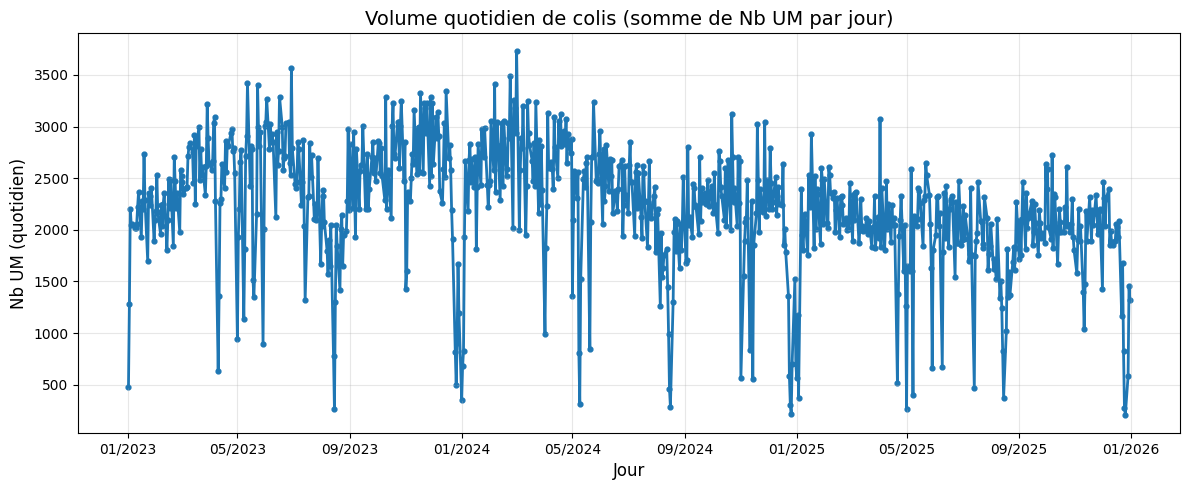

In [18]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter

# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(daily_packages_87.index, daily_packages_87.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(daily_packages_87.index, daily_packages_87.values, color="#1f77b4", s=12)

plt.tight_layout()


In [17]:
s = daily_packages_87.copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()   # ensure chronological order

# ---- Fold Saturdays: add to previous row ----
sat_mask = s.index.dayofweek == 5    # Saturdays
sat_positions = [s.index.get_loc(d) for d in s.index[sat_mask]]

for pos in sat_positions:
    if pos > 0:  # ensure there *is* a previous row
        s.iloc[pos - 1] += s.iloc[pos]   # add Saturday to previous row

# remove Saturdays
s = s[~sat_mask]

# ---- Fold Sundays: add to next row ----
sun_mask = s.index.dayofweek == 6    # Sundays
sun_positions = [s.index.get_loc(d) for d in s.index[sun_mask]]

# careful: iterate in reverse so shifting index doesn't affect upcoming positions
for pos in reversed(sun_positions):
    if pos < len(s) - 1:  # ensure there is a next row
        s.iloc[pos + 1] += s.iloc[pos]   # add Sunday to next row

# remove Sundays
s = s[~sun_mask]

## final sorted series
daily_packages_87 = s.sort_index(ascending=False)



In [19]:
daily_packages_87.head()

warehouse_day
2025-12-31    1322.0
2025-12-30    1454.0
2025-12-29     586.0
2025-12-26     211.0
2025-12-25     279.0
Name: total_nb_um, dtype: float64

In [22]:
daily_packages_87.to_frame(name="total_nb_um") \
                 .reset_index() \
                 .rename(columns={"index": "warehouse_day"}) \
                 .to_csv("daily_packages_inbound.csv", index=False)


In [2]:
folder_path = "/Users/guelbi/Desktop/explore/gr-forecast-ds-master/NTW-26134"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep=";", encoding="ISO-8859-1", on_bad_lines='skip', engine='python')  # only read selected columns
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
combined['Client file number'] = combined['Client file number'].str.replace(r'^="|"$', '', regex=True)

/var/folders/kz/2wc2rwt172q17drv43vy56cr0000gn/T/ipykernel_23222/641596494.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(dfs, ignore_index=True)


In [ ]:
# Ensure the date column is datetime
combined = combined[(combined['PLATFORM_ID'] == 'LYON')]
combined['real_start_date'] = pd.to_datetime(combined['real_start_date'], dayfirst=False, errors='coerce')

# Sort so the earliest date per package comes first
df_sorted = combined.sort_values(['Client file number', 'real_start_date'], ascending=[True, True])
# Keep the first occurrence per package
combined = df_sorted.drop_duplicates(subset='Client file number', keep='first')

In [4]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 917615 entries, 12821778 to 2315725
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Client file number         917615 non-null  object        
 1   Parcel_no                  917615 non-null  object        
 2   PLATFORM_ID                917615 non-null  object        
 3   real_start_date            917615 non-null  datetime64[ns]
 4   EVENT_ID                   917615 non-null  object        
 5   EVENT_SUB_ID               917615 non-null  object        
 6   MEANING                    917615 non-null  object        
 7   EVENT_TEXT                 9539 non-null    object        
 8   REFERENCE_NO               917461 non-null  object        
 9   SCAN_OPERATION_ID          917615 non-null  object        
 10  PARCEL_DISCREPANCY_STATUS  917615 non-null  object        
 11  EVENT_ORIGIN_KIND          917615 non-null  objec

In [ ]:
pickup = combined[(combined['PLATFORM_ID'] == 'LYON') & (combined['DEP_PLATFORM'] == 'LYON')]
inbound = combined[(combined['PLATFORM_ID'] == 'LYON') & (combined['DEP_PLATFORM'] != 'LYON')]

In [7]:
inbound.info()

<class 'pandas.core.frame.DataFrame'>
Index: 513586 entries, 12821778 to 22735677
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Client file number         513586 non-null  object        
 1   Parcel_no                  513586 non-null  object        
 2   PLATFORM_ID                513586 non-null  object        
 3   real_start_date            513586 non-null  datetime64[ns]
 4   EVENT_ID                   513586 non-null  object        
 5   EVENT_SUB_ID               513586 non-null  object        
 6   MEANING                    513586 non-null  object        
 7   EVENT_TEXT                 8402 non-null    object        
 8   REFERENCE_NO               513477 non-null  object        
 9   SCAN_OPERATION_ID          513586 non-null  object        
 10  PARCEL_DISCREPANCY_STATUS  513586 non-null  object        
 11  EVENT_ORIGIN_KIND          513586 non-null  obje

In [14]:
pickup.packing_units.max()

np.float64(151.0)

In [29]:
pickup['REFERENCE_NO'].nunique()

472

In [30]:
inbound['REFERENCE_NO'].nunique()

13786

In [31]:
voyage_col = "REFERENCE_NO"  
voyage_agg = (
    inbound.groupby(voyage_col, as_index=False)
      .agg(
          earliest_ts=("real_start_date", "min"),   # earliest timestamp for the voyage
          total_nb_um=("packing_units", "sum")       # total packages across all voyage rows
      )
)
voyage_agg["warehouse_day"] = (voyage_agg["earliest_ts"] - pd.Timedelta(hours=5)).dt.floor("D")

In [32]:
voyage_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13786 entries, 0 to 13785
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   REFERENCE_NO   13786 non-null  object        
 1   earliest_ts    13786 non-null  datetime64[ns]
 2   total_nb_um    13786 non-null  float64       
 3   warehouse_day  13786 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 430.9+ KB


In [33]:
date_col = "warehouse_day"
count_col = "total_nb_um"

day = voyage_agg[date_col].dt.date   # returns Python date objects
# Alternatively: day = df[date_col].dt.floor("D")  # keeps pandas datetime midnight

voyage_agg[count_col] = pd.to_numeric(voyage_agg[count_col], errors="coerce")

df_clean = voyage_agg.dropna(subset=[date_col, count_col])

# 4) Group by day and sum
daily_packages_26 = (
    df_clean
    .groupby(day)[count_col]
    .sum()
    .sort_index()
)

daily_packages_26=daily_packages_26[daily_packages_26<5000]

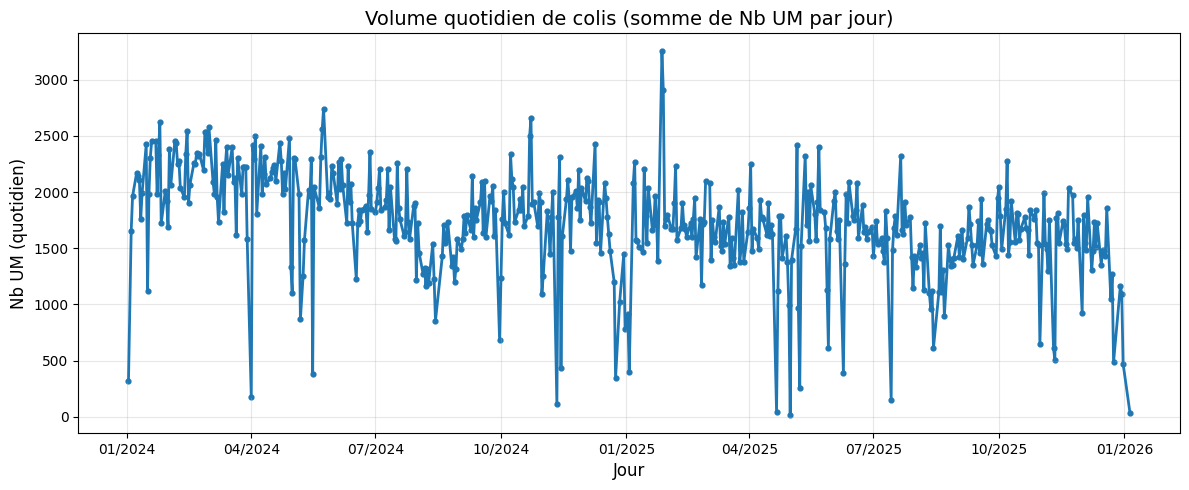

In [43]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter

# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(daily_packages_26.index, daily_packages_26.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(daily_packages_26.index, daily_packages_26.values, color="#1f77b4", s=12)

plt.tight_layout()



In [35]:
s = daily_packages_26.copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()   # ensure chronological order

# ---- Fold Saturdays: add to previous row ----
sat_mask = s.index.dayofweek == 5    # Saturdays
sat_positions = [s.index.get_loc(d) for d in s.index[sat_mask]]

for pos in sat_positions:
    if pos > 0:  # ensure there *is* a previous row
        s.iloc[pos - 1] += s.iloc[pos]   # add Saturday to previous row

# remove Saturdays
s = s[~sat_mask]

# ---- Fold Sundays: add to next row ----
sun_mask = s.index.dayofweek == 6    # Sundays
sun_positions = [s.index.get_loc(d) for d in s.index[sun_mask]]

# careful: iterate in reverse so shifting index doesn't affect upcoming positions
for pos in reversed(sun_positions):
    if pos < len(s) - 1:  # ensure there is a next row
        s.iloc[pos + 1] += s.iloc[pos]   # add Sunday to next row

# remove Sundays
s = s[~sun_mask]

## final sorted series
daily_packages_26 = s.sort_index(ascending=False)



In [36]:
daily_packages_inbound=daily_packages_inbound.sort_index(ascending = False)
daily_packages_87=daily_packages_87.sort_index(ascending = False)
daily_packages_26=daily_packages_26.sort_index(ascending = False)

In [37]:
daily_packages_26.head(20)

warehouse_day
2026-01-05      39.0
2025-12-31     473.0
2025-12-30    1097.0
2025-12-29    1167.0
2025-12-24     486.0
2025-12-23    1267.0
2025-12-22    1049.0
2025-12-19    1860.0
2025-12-18    1433.0
2025-12-17    1473.0
2025-12-16    1487.0
2025-12-15    1355.0
2025-12-12    1724.0
2025-12-11    1511.0
2025-12-10    1735.0
2025-12-09    1477.0
2025-12-08    1306.0
2025-12-05    1957.0
2025-12-04    1481.0
2025-12-03    1544.0
Name: total_nb_um, dtype: float64

In [38]:
daily_packages_87.head(20)

warehouse_day
2025-12-31    1322.0
2025-12-30    1454.0
2025-12-29     586.0
2025-12-26     211.0
2025-12-25     279.0
2025-12-24     825.0
2025-12-23    1683.0
2025-12-22    1164.0
2025-12-19    2089.0
2025-12-18    1929.0
2025-12-17    2023.0
2025-12-16    2059.0
2025-12-15    1893.0
2025-12-12    1855.0
2025-12-11    1878.0
2025-12-10    1991.0
2025-12-09    1853.0
2025-12-08    2395.0
2025-12-05    2302.0
2025-12-04    2038.0
Name: total_nb_um, dtype: float64

In [39]:
daily_packages_inbound.head(20)

warehouse_day
2025-12-31     155
2025-12-30     891
2025-12-29    1151
2025-12-24     255
2025-12-23    1245
2025-12-22     856
2025-12-19    1554
2025-12-18    1535
2025-12-17    1490
2025-12-16    1344
2025-12-15    1372
2025-12-12    1694
2025-12-11    1428
2025-12-10    1696
2025-12-09    1392
2025-12-08    1365
2025-12-05    1806
2025-12-04    1574
2025-12-03    1657
2025-12-02    1728
Name: total_nb_um, dtype: int64

In [15]:
voyage_agg

,REFERENCE_NO,earliest_ts,total_nb_um,warehouse_day
0,001,2024-01-04 08:58:00,1144.0,2024-01-04
1,002,2025-02-03 17:06:00,499.0,2025-02-03
2,003,2025-01-27 18:05:00,237.0,2025-01-27
3,004,2025-01-28 17:17:00,66.0,2025-01-28
4,9,2024-01-02 21:05:00,506812.0,2024-01-02
...,...,...,...,...
467,T51426301110,2024-11-29 18:45:00,44.0,2024-11-29
468,T51426312170,2024-12-17 19:00:00,2.0,2024-12-17
469,T51426328000,2025-01-21 18:49:00,47.0,2025-01-21
470,T51426423630,2025-06-25 18:37:00,5.0,2025-06-25


In [20]:
voyage_col = "REFERENCE_NO"  
voyage_agg = (
    pickup.groupby(voyage_col, as_index=False)
      .agg(
          earliest_ts=("real_start_date", "min"),   # earliest timestamp for the voyage
          total_nb_um=("packing_units", "sum")       # total packages across all voyage rows
      )
)
voyage_agg["warehouse_day"] = (voyage_agg["earliest_ts"] - pd.Timedelta(hours=5)).dt.floor("D")

In [21]:
date_col = "warehouse_day"
count_col = "total_nb_um"

day = voyage_agg[date_col].dt.date   # returns Python date objects
# Alternatively: day = df[date_col].dt.floor("D")  # keeps pandas datetime midnight

#voyage_agg[count_col] = pd.to_numeric(voyage_agg[count_col], errors="coerce")

df_clean = voyage_agg#.dropna(subset=[date_col, count_col])

# 4) Group by day and sum
daily_pickup = (
    df_clean
    .groupby(day)[count_col]
    .sum()
    .sort_index()
)

daily_pickup=daily_pickup[daily_pickup<1000]

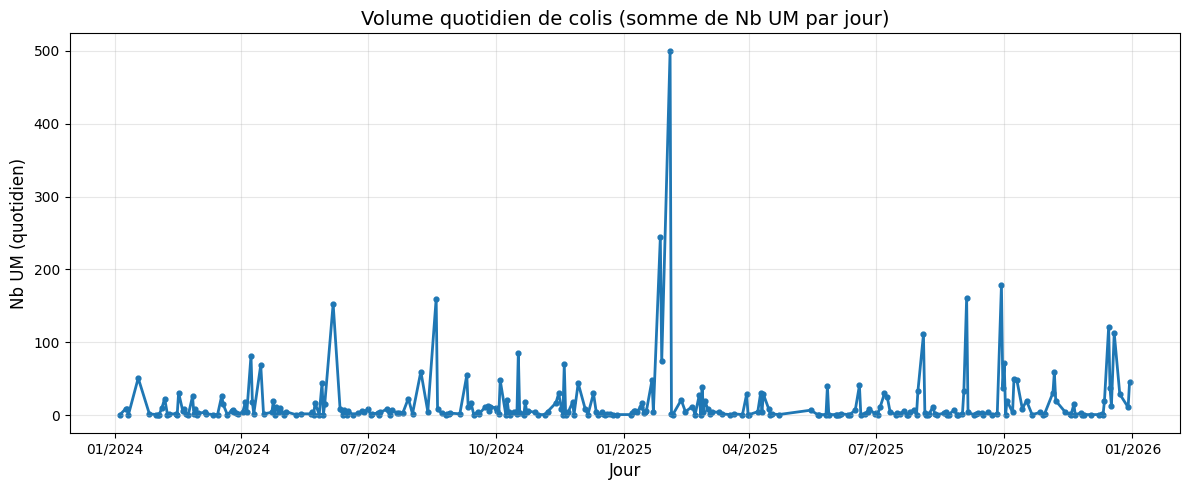

In [22]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter

# -------------------------
# Tracé du graphique
# -------------------------
plt.figure(figsize=(12, 5))

# Courbe
plt.plot(daily_pickup.index, daily_pickup.values, color="#1f77b4", linewidth=2)

# Titre et axes (en français)
plt.title("Volume quotidien de colis (somme de Nb UM par jour)", fontsize=14)
plt.xlabel("Jour", fontsize=12)
plt.ylabel("Nb UM (quotidien)", fontsize=12)

# Mise en forme des dates sur l’axe X
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
formatter.scaled[1.0] = "%d/%m/%Y"     # jours
formatter.scaled[30.0] = "%m/%Y"       # mois
formatter.scaled[365.0] = "%Y"         # années

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
plt.grid(True, alpha=0.3)

# Option: points sur la courbe pour faciliter la lecture
plt.scatter(daily_pickup.index, daily_pickup.values, color="#1f77b4", s=12)

plt.tight_layout()

